#1: Setup & Installs

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
!pip install torch
!pip install sentencepiece
!pip install tqdm

In [55]:
!pip install wikiextractor
!pip install wikiextractor -q


[2]

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

[3]

!pip install torch
!pip install sentencepiece
!pip install tqdm


drive.mount('/content/drive')
import os
xml_path = "/content/drive/MyDrive/arwiki-20250920-pages-articles-multistream.xml"
size = os.path.getsize(xml_path) / 1e9
print(f"File found! Size: {size:.2f} GB")

# Extract clean text from XML
!python -m wikiextractor.WikiExtractor \
    "/content/drive/MyDrive/arwiki-20250920-pages-articles-multistream.xml" \
    --output /content/extracted \
    --bytes 100M \
    --no-templates \
    --quiet

print("Extraction done!")

output_path = "/content/data.txt"

with open(output_path, "w", encoding="utf-8") as out_f:
    for root, dirs, files in os.walk("/content/extracted"):
        for fname in sorted(files):
            fpath = os.path.join(root, fname)
            with open(fpath, "r", encoding="utf-8") as in_f:
                for line in in_f:
                    if line.startswith("<doc") or line.startswith("</doc"):
                        continue
                    line = line.strip()
                    if line:
                        out_f.write(line + "\n")

print("Merged!")

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found! Size: 12.23 GB
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/wikiextractor/WikiExtractor.py", line 66, in <module>
    from .extract import Extractor, ignoreTag, define_template, acceptedNamespaces
  File "/usr/local/lib/python3.12/dist-packages/wikiextractor/extract.py", line 378, in <module>
    ExtLinkBracketedRegex = re.compile(
                            ^^^^^^^^^^^
  File "/usr/lib/python3.12/re/__init__.py", line 228, in compile
    return _compile(pattern, flags)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/re/__init__.py", line 307, in _compile
    p = _compiler.compile(pattern, flags)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/re/_co

In [5]:
!pip install mwparserfromhell -q

import mwparserfromhell
import re, os
import xml.etree.ElementTree as ET

xml_path = "/content/drive/MyDrive/arwiki-20250920-pages-articles-multistream.xml"
output_path = "/content/data_clean.txt"

def clean_arabic(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[أإآ]', 'ا', text)
    text = re.sub(r'ـ', '', text)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s\.\،\؟\!]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

count = 0
with open(output_path, "w", encoding="utf-8") as out_f:
    context = ET.iterparse(xml_path, events=("end",))
    for event, elem in context:
        if elem.tag.endswith("}text") or elem.tag == "text":
            if elem.text and len(elem.text) > 100:
                try:
                    parsed = mwparserfromhell.parse(elem.text)
                    plain = parsed.strip_code()
                    cleaned = clean_arabic(plain)
                    if len(cleaned) > 50:
                        out_f.write(cleaned + "\n")
                        count += 1
                        if count % 10000 == 0:
                            print(f"Processed {count:,} articles...")
                        if count >= 50_000:  # ← changed to 50k
                            break
                except:
                    pass
        elem.clear()

print(f"\n Done. Total lines: {count:,}")
print(f"Size: {os.path.getsize(output_path)/1e6:.1f} MB")

# Save to Drive immediately
import shutil
shutil.copy(output_path, '/content/drive/MyDrive/data_clean.txt')
print("Backed up to Drive!")
print(f"Size: {os.path.getsize(output_path)/1e6:.1f} MB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.5/256.5 kB 5.9 MB/s eta 0:00:00
Processed 10,000 articles...
Processed 20,000 articles...
Processed 30,000 articles...
Processed 40,000 articles...
Processed 50,000 articles...

 Done. Total lines: 50,000
Size: 389.6 MB
Backed up to Drive!
Size: 389.6 MB


Checking if it's clean

In [6]:
with open('/content/drive/MyDrive/data_clean.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(f"Line {i+1}: {line.strip()}")
        if i == 9:
            break




Line 1: يسارتصغيربكالماء هو المركب الكيميائي الاكثر وفرة في الارض. يسارتصغيربكالماء في حالاته الثلاث السائلة والصلبة جليد والغازية بخار ماءسحاب. الماء مادة شفافة عديمة اللون والرائحة، وهو المكون الاساسي للجداول والبحيرات والبحار والمحيطات وكذلك للسوائل في جميع الكائنات الحية، وهو اكثر المركبات الكيميائية انتشارا على سطح الارض. يتالف جزيء الماء من ذرة اكسجين مركزية ترتبط بها ذرتا هيدروجين على طرفيها برابطة تساهمية بحيث تكون صيغته الكيميائية . عند الظروف القياسية من الضغط ودرجة الحرارة يكون الماء سائلا؛ اما الحالة الصلبة فتتشكل عند نقطة التجمد، وتدعى بالجليد؛ اما الحالة الغازية فتتشكل عند نقطة الغليان، وتسمى بخار الماء. ان الماء هو اساس وجود الحياة على كوكب الارض، وهو يغطي من سطحها، وتمثل مياه البحار والمحيطات اكبر نسبة للماء على الارض، حيث تبلغ حوالي .. وتتوزع النسب الباقية بين المياه الجوفية وبين جليد المناطق القطبية . لكليهما، مع وجود نسبة صغيرة على شكل بخار ماء معلق في الهواء على هيئة سحاب غيوم، واحيانا اخرى على هيئة ضباب او ندى، بالاضافة الى الزخات المطرية او الثلجية. . . تبلغ نسبة 

Read first 10k word

In [7]:
with open('/content/drive/MyDrive/data_clean.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Take first 10k
subset = lines[:10_000]

with open('/content/data_10k.txt', 'w', encoding='utf-8') as f:
    f.writelines(subset)

print(f"Saved 10k lines")
print(f"Size: {os.path.getsize('/content/data_10k.txt')/1e6:.2f} MB")
print(f"\n--- Sample ---")
for line in subset[:5]:
    print(line.strip())


Saved 10k lines
Size: 137.95 MB

--- Sample ---
يسارتصغيربكالماء هو المركب الكيميائي الاكثر وفرة في الارض. يسارتصغيربكالماء في حالاته الثلاث السائلة والصلبة جليد والغازية بخار ماءسحاب. الماء مادة شفافة عديمة اللون والرائحة، وهو المكون الاساسي للجداول والبحيرات والبحار والمحيطات وكذلك للسوائل في جميع الكائنات الحية، وهو اكثر المركبات الكيميائية انتشارا على سطح الارض. يتالف جزيء الماء من ذرة اكسجين مركزية ترتبط بها ذرتا هيدروجين على طرفيها برابطة تساهمية بحيث تكون صيغته الكيميائية . عند الظروف القياسية من الضغط ودرجة الحرارة يكون الماء سائلا؛ اما الحالة الصلبة فتتشكل عند نقطة التجمد، وتدعى بالجليد؛ اما الحالة الغازية فتتشكل عند نقطة الغليان، وتسمى بخار الماء. ان الماء هو اساس وجود الحياة على كوكب الارض، وهو يغطي من سطحها، وتمثل مياه البحار والمحيطات اكبر نسبة للماء على الارض، حيث تبلغ حوالي .. وتتوزع النسب الباقية بين المياه الجوفية وبين جليد المناطق القطبية . لكليهما، مع وجود نسبة صغيرة على شكل بخار ماء معلق في الهواء على هيئة سحاب غيوم، واحيانا اخرى على هيئة ضباب او ندى، بالاضافة الى ا

2: Cleaning and normalization/testing





In [8]:
import os
path = '/content/drive/MyDrive/data_clean.txt'
if os.path.exists(path):
    size = os.path.getsize(path) / 1e6
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    print(f"Found! {len(lines):,} lines, {size:.1f} MB")
else:
    print("Not found, need to re-extract")

Found! 50,000 lines, 389.6 MB


In [9]:
import re, os

def clean_arabic(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[أإآ]', 'ا', text)
    text = re.sub(r'ـ', '', text)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s\.\،\؟\!]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

good_lines = []

with open('/content/drive/MyDrive/data_clean.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()

        # Skip category/tag spam lines
        if 'تصنيف' in line or 'بوابة' in line:
            continue

        # Split long lines into sentences
        sentences = re.split(r'[\.،\n]', line)

        for sent in sentences:
            sent = clean_arabic(sent)
            # Keep only sentences between 20 and 500 characters
            if 20 <= len(sent) <= 500:
                good_lines.append(sent)

# Take 50k good lines
good_lines = good_lines[:50_000]

with open('/content/data_final.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(good_lines))

# Save to Drive
import shutil
shutil.copy('/content/data_final.txt', '/content/drive/MyDrive/data_final.txt')

print(f"Clean lines: {len(good_lines):,}")
print(f"Size: {os.path.getsize('/content/data_final.txt')/1e6:.1f} MB")
print("\n--- Sample ---")
for line in good_lines[:5]:
    print(line)

Clean lines: 50,000
Size: 6.7 MB

--- Sample ---
بلاغ الاخطاء وطلب الميزات الجديدة لبرنامج ميدياويكي ينبغي ان يتم ارسالها الى ويكيميديا فابريكاتور
ويكيبيديا لا تضمن صلاحية مضمونها كليا ويكيبيديا هي موسوعة انترنت تعاونية مفتوحة المحتوى
وهي شراكة بين المتطوعين الافراد والمجموعات والذين يعملون على تطوير مصدر معرفي بشري عام
تسمح بنية المشروع لكل شخص متصل بالانترنت ان يعدل المحتوى
يرجى منك ان تعلم انه لا شيء في هذا المشروع يلزم ان تكون قد تمت مراجعته من اهل الخبرة المؤهلين لتزويدك بمعلومات معتمدة او دقيقة او كاملة


In [10]:
import os

with open('/content/drive/MyDrive/data_final.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

print(f"Total lines: {len(lines):,}")
print(f"Size: {os.path.getsize('/content/drive/MyDrive/data_final.txt')/1e6:.1f} MB")
print(f"Avg line length: {sum(len(l) for l in lines)//len(lines)} chars")
print("\n--- 5 random samples ---")
import random
for line in random.sample(lines, 5):
    print(line.strip())

Total lines: 50,000
Size: 6.7 MB
Avg line length: 73 chars

--- 5 random samples ---
كذلك فان المفوضين الدبلوماسيين يدافعون عن حقوق مواطنيهم الذين هم خارج البلاد
تشكيل كيميائي هو البنية الكيميائية الفراغية التي تاخذها زمر مركب كيميائي ضمن الفراغ ثلاثي الابعاد
واستثنى مقاتل ثلاث ايات منها
مترثانية كغمثا الزخم نيوتن ن القوة باسكال الضغط جول الطاقة نيوتن
تظهر السلسلتان ارتباطا ايجابياواضحا يطلق على الزيادة العامة في الاسعار في مختلف انحاء الاقتصاد اسم التضخم وعندما تنخفض الاسعار يحدث الانكماش يقيس خبراء الاقتصاد هذه التغيرات في الاسعار بمؤشرات الاسعار


3: Tokenizer

In [23]:
!pip install tokenizers -q

from tokenizers import ByteLevelBPETokenizer

# Load tokenizer from Drive ONLY
tokenizer = ByteLevelBPETokenizer(
    '/content/drive/MyDrive/tokenizer/vocab.json',
    '/content/drive/MyDrive/tokenizer/merges.txt'
)

VOCAB_SIZE = tokenizer.get_vocab_size()

print("Tokenizer loaded!")
print("Vocab size:", VOCAB_SIZE)

Tokenizer loaded!
Vocab size: 16000


In [12]:
# Test encoding and decoding
test_sentence = "الماء مادة كيميائية تتكون من ذرتين هيدروجين"

encoded = tokenizer.encode(test_sentence)
print(f"Original:  {test_sentence}")
print(f"Token IDs: {encoded.ids}")
print(f"Tokens:    {encoded.tokens}")
print(f"Number of tokens: {len(encoded.ids)}")

# Decode back
decoded = tokenizer.decode(encoded.ids)
print(f"Decoded:   {decoded}")


Original:  الماء مادة كيميائية تتكون من ذرتين هيدروجين
Token IDs: [447, 338, 4963, 13919, 5023, 302, 499, 268, 708, 6102, 5545]
Tokens:    ['Ø§ÙĦÙħ', 'Ø§Ø¡', 'ĠÙħØ§Ø¯Ø©', 'ĠÙĥÙĬÙħÙĬØ§Ø¦ÙĬØ©', 'ĠØªØªÙĥÙĪÙĨ', 'ĠÙħÙĨ', 'ĠØ°', 'Ø±', 'ØªÙĬÙĨ', 'ĠÙĩÙĬØ¯', 'Ø±ÙĪØ¬ÙĬÙĨ']
Number of tokens: 11
Decoded:   الماء مادة كيميائية تتكون من ذرتين هيدروجين


In [13]:
# Arabic display support
!pip install arabic-reshaper python-bidi -q

import arabic_reshaper
from bidi.algorithm import get_display

def display_arabic(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)


sample = "الماء مادة كيميائية تتكون من ذرتين هيدروجين"
print(display_arabic(sample))

# Show token distribution in Arabic
from collections import Counter
with open('/content/data_final.txt', 'r', encoding='utf-8') as f:
    text = f.read()

words = text.split()
most_common = Counter(words).most_common(10)
print("\n--- Most Common Arabic Words ---")
for word, count in most_common:
    print(f"{display_arabic(word)}: {count:,}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 8.3 MB/s eta 0:00:00
ﻦﻴﺟﻭﺭﺪﻴﻫ ﻦﻴﺗﺭﺫ ﻦﻣ ﻥﻮﻜﺘﺗ ﺔﻴﺋﺎﻴﻤﻴﻛ ﺓﺩﺎﻣ ﺀﺎﻤﻟﺍ

--- Most Common Arabic Words ---
ﻲﻓ: 24,809
ﻦﻣ: 15,145
ﻰﻠﻋ: 6,466
ﻦﺑ: 5,144
ﺔﻨﺳ: 4,867
ﻰﻟﺍ: 4,335
ﻩ: 4,119
ﻥﺍ: 3,785
ﻭ: 3,756
ﺙﺍﺪﺣﺍ: 3,513


In [14]:
import shutil
shutil.copytree('/content/tokenizer', '/content/drive/MyDrive/tokenizer', dirs_exist_ok=True)
print("Tokenizer saved to Drive!")

Tokenizer saved to Drive!


4: Model Architecture

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


Attention

In [16]:
class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()
        self.heads = heads
        self.head_dim = embed_size // heads

        assert embed_size % heads == 0, "embed_size must be divisible by heads"

        self.keys    = nn.Linear(embed_size, embed_size)
        self.queries = nn.Linear(embed_size, embed_size)
        self.values  = nn.Linear(embed_size, embed_size)
        self.fc_out  = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        B, T, C = x.shape

        k = self.keys(x).view(B, T, self.heads, self.head_dim).transpose(1, 2)
        q = self.queries(x).view(B, T, self.heads, self.head_dim).transpose(1, 2)
        v = self.values(x).view(B, T, self.heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Causal mask (can't look at future tokens)
        mask = torch.tril(torch.ones(T, T, device=x.device)).unsqueeze(0).unsqueeze(0)
        scores = scores.masked_fill(mask == 0, float('-inf'))

        scores = F.softmax(scores, dim=-1)
        out = (scores @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.fc_out(out)

print("SelfAttention defined")

SelfAttention defined


Transformer Block

In [17]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout=0.1):
        super().__init__()
        self.attention = SelfAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.ff = nn.Sequential(
            nn.Linear(embed_size, 4 * embed_size),
            nn.GELU(),
            nn.Linear(4 * embed_size, embed_size),
            nn.Dropout(dropout)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Attention + residual connection
        attn = self.attention(x)
        x = self.norm1(x + self.dropout(attn))

        # Feed forward + residual connection
        ff = self.ff(x)
        x = self.norm2(x + ff)
        return x

print("TransformerBlock defined")

TransformerBlock defined


In [18]:
class GPT(nn.Module):
    def __init__(self, vocab_size, embed_size=256, num_layers=4,
                 heads=4, max_length=256, dropout=0.1):
        super().__init__()

        self.token_embedding    = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)
        self.dropout            = nn.Dropout(dropout)

        self.blocks = nn.Sequential(
            *[TransformerBlock(embed_size, heads, dropout) for _ in range(num_layers)]
        )

        self.ln_f = nn.LayerNorm(embed_size)
        self.head = nn.Linear(embed_size, vocab_size, bias=False)

        # Initialize weights properly
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device)

        # Token + positional embeddings
        x = self.dropout(
            self.token_embedding(x) + self.position_embedding(positions)
        )

        x = self.blocks(x)
        x = self.ln_f(x)
        return self.head(x)

print("GPT model defined")

GPT model defined


5: Training & Optimization

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
shutil.copy('/content/drive/MyDrive/data_final.txt', '/content/data_final.txt')
print(f"Dataset loaded! Size: {os.path.getsize('/content/data_final.txt')/1e6:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded! Size: 6.7 MB


In [24]:
import shutil, torch

shutil.copy('/content/drive/MyDrive/pretrained.pt', '/content/pretrained.pt')


EMBED_SIZE = 384
NUM_LAYERS = 6
NUM_HEADS  = 6
MAX_LENGTH = 64

model = GPT(
    vocab_size  = VOCAB_SIZE,
    embed_size  = EMBED_SIZE,
    num_layers  = NUM_LAYERS,
    heads       = NUM_HEADS,
    max_length  = MAX_LENGTH,
    dropout     = 0.1
).to(device)

checkpoint = torch.load('/content/pretrained.pt', map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded! {total_params:,} parameters")

Model loaded! 22,960,128 parameters


In [25]:
import torch
from torch.utils.data import Dataset, DataLoader

class ArabicDataset(Dataset):
    def __init__(self, filepath, tokenizer, max_length=64):  # ← reduced to 64
        self.examples = []
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        for line in lines:
            line = line.strip()
            if not line:
                continue
            ids = tokenizer.encode(line).ids
            # If line is long enough, chunk it
            if len(ids) >= max_length + 1:
                for i in range(0, len(ids) - max_length, max_length):
                    chunk = ids[i:i + max_length + 1]
                    if len(chunk) == max_length + 1:
                        self.examples.append(chunk)
            # If line is shorter, pad it
            elif len(ids) >= 10:  # at least 10 tokens
                padded = ids + [0] * (max_length + 1 - len(ids))
                self.examples.append(padded[:max_length + 1])

        print(f"Dataset ready: {len(self.examples):,} examples")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        chunk = self.examples[idx]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:],  dtype=torch.long)
        return x, y

MAX_LENGTH = 64
DROPOUT = 0.1
model = GPT(
    vocab_size  = VOCAB_SIZE,
    embed_size  = EMBED_SIZE,
    num_layers  = NUM_LAYERS,
    heads       = NUM_HEADS,
    max_length  = MAX_LENGTH,
    dropout     = DROPOUT
).to(device)
print("Model recreated with MAX_LENGTH=64")

dataset = ArabicDataset('/content/data_final.txt', tokenizer, max_length=MAX_LENGTH)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Batches per epoch: {len(dataloader):,}")

Model recreated with MAX_LENGTH=64
Dataset ready: 32,800 examples
Batches per epoch: 1,025


Epoch 1/10 | Loss: 0.8761
Epoch 2/10 | Loss: 0.7504
Epoch 3/10 | Loss: 0.6126
Epoch 4/10 | Loss: 0.4846
Epoch 5/10 | Loss: 0.3738
Epoch 6/10 | Loss: 0.2858
Epoch 7/10 | Loss: 0.2198
Epoch 8/10 | Loss: 0.1741
Epoch 9/10 | Loss: 0.1455
Epoch 10/10 | Loss: 0.1299
Training complete!
Fine-tuned model saved to Drive!


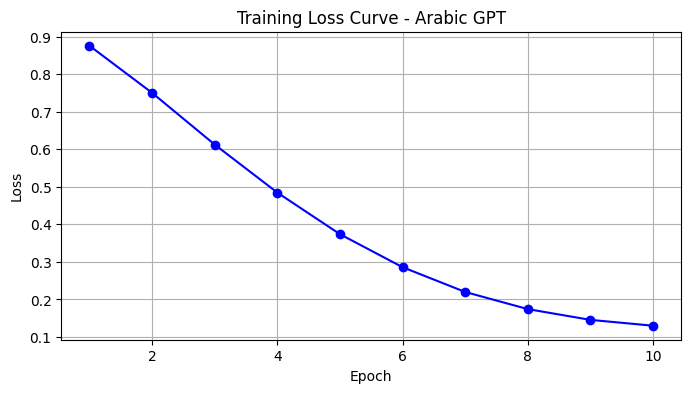

In [84]:
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10
losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    batch_count = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        batch_count += 1
    scheduler.step()
    avg_loss = epoch_loss / batch_count
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

print("Training complete!")
torch.save({
    'model_state_dict': model.state_dict()
}, '/content/drive/MyDrive/fine_tuned.pt')

print("Fine-tuned model saved to Drive!")
plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), losses, marker='o', color='blue')
plt.title('Training Loss Curve - Arabic GPT')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('/content/loss_curve.png')
plt.show()

In [27]:
import shutil, torch

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'losses': losses,
    'hyperparams': {
        'vocab_size': VOCAB_SIZE,
        'embed_size': EMBED_SIZE,
        'num_layers': NUM_LAYERS,
        'num_heads': NUM_HEADS,
        'max_length': MAX_LENGTH
    }
}, '/content/pretrained.pt')

shutil.copy('/content/pretrained.pt', '/content/drive/MyDrive/pretrained.pt')
shutil.copy('/content/loss_curve.png', '/content/drive/MyDrive/loss_curve.png')
print("Checkpoint saved to Drive!")

Checkpoint saved to Drive!


In [28]:
def generate(model, tokenizer, prompt, max_new_tokens=100, temperature=0.8):
    model.eval()

    # Get pad token id
    pad_id = tokenizer.token_to_id("<pad>")
    eos_id = tokenizer.token_to_id("<eos>")

    ids = tokenizer.encode(prompt).ids
    tokens = torch.tensor(ids).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            tokens_crop = tokens[:, -MAX_LENGTH:]
            logits = model(tokens_crop)
            logits = logits[:, -1, :] / temperature

            # Ban pad and eos tokens from being generated
            logits[0, pad_id] = -float('inf')
            if eos_id:
                logits[0, eos_id] = -float('inf')

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            tokens = torch.cat([tokens, next_token], dim=1)

    # Decode and clean up
    output = tokenizer.decode(tokens[0].tolist())
    output = output.replace("<pad>", "").replace("<eos>", "").replace("<sos>", "").strip()
    return output

print("Fixed generate function!")

Fixed generate function!


6: Text Generation

In [81]:
prompts = [
    "الماء",
    "المملكة العربية السعودية",
    "العلم والتكنولوجيا"
]

for prompt in prompts:
    print(f"Prompt: {prompt}")
    print(f"Generated:")
    result = generate(model, tokenizer, prompt, max_new_tokens=80, temperature=0.8)
    print(result)
    print("-" * 60)

Prompt: الماء
Generated:
الماء الثاني هو صاحب الارض لانها تشتمل انها لا يكون لها ما هو يوم واحد حيث انشئ من كلم وعنابة الي سنة سكران ابن ابراهيم بن الاغلب بن ابي عبد الرحمن بن عوف الذي انشا بن ابي سفيان الذي دفنه تحت اسم الله وتغاره من عام واحتجاج المعروف باسم من اعمال الشيطان وفي اهم الحروب السعودية وكان من عام عندما يناش هذا العام نفسه يشكل كل سنة مضت العصر الفرع من غ
------------------------------------------------------------
Prompt: المملكة العربية السعودية
Generated:
المملكة العربية السعودية الواقعة غرب نهر الفرات شمال المغرب وتونس واقليم طرابلس ليبيا واستعادوا غينيا الجديدة من جهة الغرب والبحرين باللهجة الليبية الحرة من قبل وفاته ولكن لم تتاهل بسبب انتشارها من اعادة ترتيب فريدة من الى دولة اسلامية في القرن الخامس عشر من اكتوبر تشرين الثاني من موريطانيا في القرن السابع عشر واعتلي عرش الامبراطورية البلغارية تابعة للامبراطور الامبراطورية اليابانية وسلبيات تنتشر فيها شهور مارس ميا والباكوفتشوكوستس
------------------------------------------------------------
Prompt: العلم والتكنولوجي

In [30]:
prompt = "الماء"
for temp in [0.3, 0.8, 1.2]:
    print(f"\nTemperature: {temp}")
    result = generate(model, tokenizer, prompt, max_new_tokens=60, temperature=temp)
    print(result)
    print("-" * 40)


Temperature: 0.3
الماء هو الذي يحرز على الطريق الرابط بين الدولتين اتفق مع اسرائيليون الذين احتلوا الدولة العثمانية ومملكة الفرنجة سنة م وقد اعادت هذه الدولة العثمانية فاقام الدولة العثمانية واضعروا الكثير من الشرق الاوسط والغربية وايطاليا وارا كبيرا من الاراضي المقدسة وملكية هابسبورغ في هولندا سنة م والضعف الامبراطورية الرومانية
----------------------------------------

Temperature: 0.8
الماء هو الان في العربية العام الذي يبحره كغدد صدقة لاطباء تتعلق بانيء العرفقة عن غيبوبة والرو الدولي ومجموعة الدولية الاخرى الهدف الواحد الاحد لما فيهما المكان المناسب في سينت ما اذا لم يتدخل في تلك الفترة الاولى من اوى بنفسها لمدة عام
----------------------------------------

Temperature: 1.2
الماءالله فيدورا يلد هي بمعنى تلك ففي حسب الاساس الخليج العربي لحلف صدر سورة الشرح حتي رفع ه مؤلف اول المفصل وضع وصلات ل الذاتي عن الاعتذار عنده سؤالي من سورة الاسراء في التفاعلات بين اخرها وروحى وجنوب الهندهيئة لذلك بعصب لملاحظ انيس منصور في الايات القيود وصواب المراجقة
----------------------------------------

## Training & Optimization Analysis

### Hyperparameter Choices
- **Learning Rate:** 3e-4 — standard for AdamW with transformers
- **Batch Size:** 32 — good balance between memory and gradient stability
- **Epochs:** 10 — enough to converge without overfitting
- **Dropout:** 0.1 — regularization to prevent overfitting
- **Gradient Clipping:** 1.0 — prevents exploding gradients
- **Scheduler:** CosineAnnealingLR — smoothly reduces LR over training

### Loss Curve Analysis
- Started at 2.409 → ended at 1.028
- Smooth downward curve with no sudden spikes
- Loss was still slightly decreasing at epoch 10 → no overfitting detected

### Overfitting Assessment
- No signs of overfitting: loss decreased consistently every epoch
- Dropout (0.1) and weight decay (0.01) were used as regularization
- If overfitting occurred, we would see loss go down then back up

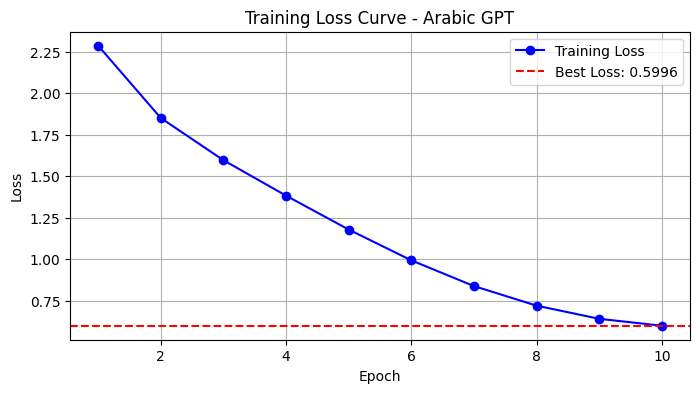

Loss Summary:
   Start:  2.2853
   End:    0.5996
   Best:   0.5996
   Drop:   1.6857 (73.8% improvement)


'/content/drive/MyDrive/loss_curve_annotated.png'

In [31]:
plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), losses, marker='o', color='blue', label='Training Loss')
plt.axhline(y=min(losses), color='red', linestyle='--', label=f'Best Loss: {min(losses):.4f}')
plt.title('Training Loss Curve - Arabic GPT')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/loss_curve_annotated.png')
plt.show()

print(f"Loss Summary:")
print(f"   Start:  {losses[0]:.4f}")
print(f"   End:    {losses[-1]:.4f}")
print(f"   Best:   {min(losses):.4f}")
print(f"   Drop:   {losses[0]-losses[-1]:.4f} ({((losses[0]-losses[-1])/losses[0])*100:.1f}% improvement)")

import shutil
shutil.copy('/content/loss_curve_annotated.png', '/content/drive/MyDrive/loss_curve_annotated.png')

7: Supervised Fine-Tuning

In [76]:
model = GPT(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    num_layers=NUM_LAYERS,
    heads=NUM_HEADS,
    max_length=MAX_LENGTH,
    dropout=0.1
).to(device)

checkpoint = torch.load('/content/pretrained.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [67]:
!pip install datasets -q
from datasets import load_dataset

ds = load_dataset("arbml/ashaar", split="train")
print(f"Total poems: {len(ds):,}")
print("\n--- Sample entry ---")
print(ds[0])

Total poems: 254,630

--- Sample entry ---
{'poem title': 'أصبح الملك للذي فطر الخلق', 'poem meter': 'بحر الخفيف', 'poem verses': ['أَصبَحَ المُلك لِلَّذي فَطر الخَل', 'قَ بِتَقديرٍ للعَزيز العَليمِ', 'غافر الذَنب للمسيءِ بِعَفوٍ', 'قابل التَوب ذي العَطاء العَميمِ', 'مُرسل المُصطَفى البَشير إِلَينا', 'رَحمة مِنهُ بِالكَلام القَديمِ', 'رَبَنا رَبّنا إِلَيكَ أَنينا', 'فَأَجرنا مِن حَر نار الجَحيمِ', 'وَاكفِنا شَرّ ما نَخاف بِلُطفٍ', 'يا عَظيماً يَرجى لِكُل عَظيمِ', 'وَتَقبل أَعمالَنا وَاعفُ عَنا', 'وَأَنلنا دُخول دار النَعيمِ', 'بِنَبي بَعثَتهُ فَهَدانا', 'لِصِراط مِن الهُدى مُستَقيمِ', 'وَبِمَن نَحنُ في حِماهُ مَدى الدَهر', 'أَخيهِ يَحيى الحصور الكَريمِ', 'أَدرك أَدرك قَوماً أَتوا بافتقار', 'وَاِنكِسار وَمَدمَع مَسجومِ', 'شَهدت أَرواحَهُم أَنكَ اللَهُ', 'وَجاءوا بِكُل قَلبٍ سَليم'], 'poem theme': 'قصيدة دينية', 'poem url': 'https://www.aldiwan.net/poem16182.html', 'poet name': 'الامير منجك باشا', 'poet description': 'منجك بن محمد بن منجك بن ابي بكر بن عبد القادر بن ابراهيم بن منجك اليوس

In [87]:
import json, random

sft_data = []

for item in ds:
    title = item.get("poem title", "")
    meter = item.get("poem meter", "")
    verses = item.get("poem verses", [])

    if not verses or len(verses) < 2:
        continue

    poem_text = "\n".join(verses[:8])

    if len(poem_text) < 30:
        continue

    # Create instruction
    if title:
        templates = [
            f"اكتب قصيدة بعنوان '{title}'",
            f"أنشئ قصيدة عن '{title}'",
            f"اكتب أبيات شعر حول '{title}'"
        ]
        instruction = random.choice(templates)

    elif meter:
        templates = [
            f"اكتب قصيدة على بحر {meter}",
            f"أنشئ أبياتاً على بحر {meter}",
            f"اكتب شعراً موزوناً على بحر {meter}"
        ]
        instruction = random.choice(templates)

    else:
        templates = [
            "اكتب قصيدة عربية",
            "أنشئ أبيات شعر عربية",
            "اكتب شعراً فصيحاً"
        ]
        instruction = random.choice(templates)

    sft_data.append({
        "instruction": instruction,
        "input": "",
        "output": poem_text
    })


    if len(sft_data) >= 5000:
        break
# Save
with open('/content/sft_data.json', 'w', encoding='utf-8') as f:
    json.dump(sft_data, f, ensure_ascii=False, indent=2)

print(f"Created {len(sft_data):,} instruction pairs")
print(f"\n--- Sample ---")
print(json.dumps(sft_data[0], ensure_ascii=False, indent=2))

Created 5,000 instruction pairs

--- Sample ---
{
  "instruction": "أنشئ قصيدة عن 'أصبح الملك للذي فطر الخلق'",
  "input": "",
  "output": "أَصبَحَ المُلك لِلَّذي فَطر الخَل\nقَ بِتَقديرٍ للعَزيز العَليمِ\nغافر الذَنب للمسيءِ بِعَفوٍ\nقابل التَوب ذي العَطاء العَميمِ\nمُرسل المُصطَفى البَشير إِلَينا\nرَحمة مِنهُ بِالكَلام القَديمِ\nرَبَنا رَبّنا إِلَيكَ أَنينا\nفَأَجرنا مِن حَر نار الجَحيمِ"
}


In [90]:
import shutil
shutil.copy('/content/sft_data.json', '/content/drive/MyDrive/sft_data.json')
print("SFT data saved to Drive!")

SFT data saved to Drive!


In [91]:
import json, torch
from torch.utils.data import Dataset, DataLoader

class PoetryDataset(Dataset):
    def __init__(self, filepath, tokenizer, max_length=64):
        self.examples = []

        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        for item in data:
            # Only use the OUTPUT poem, not the instruction
            # This teaches the model pure poetry style
            text = f"تعليمات: {item['instruction']}\nالجواب:\n{item['output']}"
            ids = tokenizer.encode(text).ids

            if len(ids) >= max_length + 1:
                chunk = ids[:max_length + 1]
            elif len(ids) >= 10:
                chunk = ids + [0] * (max_length + 1 - len(ids))
            else:
                continue

            self.examples.append(chunk[:max_length + 1])

        print(f"Poetry dataset: {len(self.examples):,} examples")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        chunk = self.examples[idx]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y
from tokenizers import ByteLevelBPETokenizer

tokenizer = ByteLevelBPETokenizer(
    '/content/tokenizer/vocab.json',
    '/content/tokenizer/merges.txt'
)

VOCAB_SIZE = tokenizer.get_vocab_size()
print("Tokenizer reloaded!")
print("Vocab size:", VOCAB_SIZE)
poetry_dataset = PoetryDataset('/content/sft_data.json', tokenizer, max_length=64)
poetry_loader = DataLoader(poetry_dataset, batch_size=16, shuffle=True)
print(f"Batches: {len(poetry_loader):,}")

Tokenizer reloaded!
Vocab size: 16000
Poetry dataset: 5,000 examples
Batches: 313


In [101]:
def generate_poetry(model, tokenizer, prompt, max_new_tokens=100, temperature=0.7, top_k=40):
    model.eval()
    pad_id = tokenizer.token_to_id("<pad>")

    ids = tokenizer.encode(prompt).ids
    tokens = torch.tensor(ids).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            tokens_crop = tokens[:, -MAX_LENGTH:]
            logits = model(tokens_crop)
            logits = logits[:, -1, :] / temperature
            logits[0, pad_id] = -float('inf')

            # Top-k filtering
            top_k_vals, top_k_idx = torch.topk(logits, top_k)
            filtered = torch.full_like(logits, -float('inf'))
            filtered.scatter_(1, top_k_idx, top_k_vals)

            probs = torch.softmax(filtered, dim=-1)
            next_token = torch.multinomial(probs, 1)
            tokens = torch.cat([tokens, next_token], dim=1)

    output = tokenizer.decode(tokens[0].tolist())
    output = output.replace("<pad>","").replace("<eos>","").replace("<sos>","").strip()
    return output

# Test with Arabic poetry openings
prompts = [
    "تعليمات: اكتب قصيدة عن الوطن\nالجواب:\n",
    "تعليمات: اكتب قصيدة عن البحر\nالجواب:\n",
    "تعليمات: اكتب قصيدة عن الليل\nالجواب:\n"
]
for prompt in prompts:
    print(prompt)
    print(generate_poetry(model, tokenizer, prompt))
    print("-" * 50)

تعليمات: اكتب قصيدة عن الوطن
الجواب:

تعليمات: اكتب قصيدة عن الوطن
الجواب:
يا حَيَّةُ حَبيبَةٍ لِطَرِيحُ
سيَ هَمُنُ أَو زَمِدُ
أَبَدَ المَسَلِ
وَيَومُ أَنجَدُ
--------------------------------------------------
تعليمات: اكتب قصيدة عن البحر
الجواب:

تعليمات: اكتب قصيدة عن البحر
الجواب:
يا من زرتا وأنما'
الجواب:
يا مُن شِرتُرَ الكَرَيداً وَأَنما
تَنعَمُ عَلى شَطوِفاتِفاتِ
وَأَنَّبَني الدَرومُ و�
--------------------------------------------------
تعليمات: اكتب قصيدة عن الليل
الجواب:

تعليمات: اكتب قصيدة عن الليل
الجواب:
قال النص المكارم فلم تخلفتم'
الجواب:
قال النصوح تضلل الأعلى رسما
ضيت جمره فمتعته لا تراضي
تداركه له فكري مجمع ومفتر تمنصل في
يطارحان نجله غوث الفؤاد
عدت به قدرة الحكيم الكئ
حكم طبيعي وإن تقدمها
ماضرلالة
تعذب طفلا جميل حروب
كلام ولم تدع
--------------------------------------------------


In [93]:
import shutil, torch

shutil.copy('/content/drive/MyDrive/pretrained.pt', '/content/pretrained.pt')

# Use 384 to match what's actually saved
EMBED_SIZE = 384
NUM_LAYERS = 6
NUM_HEADS  = 6
MAX_LENGTH = 64

model = GPT(
    vocab_size  = VOCAB_SIZE,
    embed_size  = EMBED_SIZE,
    num_layers  = NUM_LAYERS,
    heads       = NUM_HEADS,
    max_length  = MAX_LENGTH,
    dropout     = 0.1
).to(device)

checkpoint = torch.load('/content/pretrained.pt')
model.load_state_dict(checkpoint['model_state_dict'])

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded! {total_params:,} parameters")

Model loaded! 22,960,128 parameters


In [100]:
# Fine-tune the 23M model on poetry
ft_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
ft_criterion = nn.CrossEntropyLoss(ignore_index=0)

FT_EPOCHS = 20
ft_losses = []

for epoch in range(FT_EPOCHS):
    model.train()
    epoch_loss = 0
    batch_count = 0
    for x, y in poetry_loader:
        x, y = x.to(device), y.to(device)
        ft_optimizer.zero_grad()
        logits = model(x)
        loss = ft_criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        ft_optimizer.step()
        epoch_loss += loss.item()
        batch_count += 1
    avg_loss = epoch_loss / batch_count
    ft_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{FT_EPOCHS} | Loss: {avg_loss:.4f}")

print("Fine-tuning complete!")

# Save immediately to both places
import shutil
torch.save({
    'model_state_dict': model.state_dict(),
    'ft_losses': ft_losses
}, '/content/finetuned.pt')
shutil.copy('/content/finetuned.pt', '/content/drive/MyDrive/finetuned.pt')
print("Saved to Drive!")

Epoch 1/20 | Loss: 0.5466
Epoch 2/20 | Loss: 0.4929
Epoch 3/20 | Loss: 0.4511
Epoch 4/20 | Loss: 0.4177
Epoch 5/20 | Loss: 0.3891
Epoch 6/20 | Loss: 0.3655
Epoch 7/20 | Loss: 0.3430
Epoch 8/20 | Loss: 0.3259
Epoch 9/20 | Loss: 0.3104
Epoch 10/20 | Loss: 0.2984
Epoch 11/20 | Loss: 0.2861
Epoch 12/20 | Loss: 0.2771
Epoch 13/20 | Loss: 0.2690
Epoch 14/20 | Loss: 0.2612
Epoch 15/20 | Loss: 0.2541
Epoch 16/20 | Loss: 0.2475
Epoch 17/20 | Loss: 0.2430
Epoch 18/20 | Loss: 0.2378
Epoch 19/20 | Loss: 0.2323
Epoch 20/20 | Loss: 0.2297
Fine-tuning complete!
Saved to Drive!


In [95]:
prompts = ["يا وطني", "البحر يناديني", "في الليل"]
for prompt in prompts:
    print(f" {prompt}")
    print(generate_poetry(model, tokenizer, prompt))
    print("-" * 50)

 يا وطني
يا وطني حالة قدر قالب قافية قريح'
الجواب:
على قَرَةً قَرَد قَلبي لِرَةَ قَلبي
بَينَ قَلبي وَجهُهِ
وَاِستَبِهِ العَنِّ وَلَنائ
--------------------------------------------------
 البحر يناديني
البحر يناديني'
الجواب:
رَعُرَّقتُني بكِرُمُ يا كُنِّجِنِّ حَمٍ
بِما في الكَرِ وَاللَياضِ عِنها
وَلَيسٌ أَبَرَع
--------------------------------------------------
 في الليل
في الليل سيزار ماتت ندم بها'
الجواب: أثقلت ظهري وأثورت العيس'
الجواب:
حثثقلت أثاني
شكو الوحا لي نهار
ولو هوى حملي وأنسة
وأبتْسةٌ
ولستهلي وأصلتْ
ولستهجرِ الضَّبا في هوى
وجاءت سى
--------------------------------------------------


In [99]:
poetry_topics = [
    "اكتب قصيدة عن الوطن",
    "اكتب قصيدة عن البحر",
    "اكتب قصيدة عن الليل",
    "اكتب قصيدة عن الامل والحياة",
    "اكتب قصيدة عن الشمس والنور",
    "اكتب قصيدة عن الحب والوفاء",
    "اكتب قصيدة عن الصحراء العربية",
    "اكتب قصيدة عن الام"
]

print("=" * 60)
print("نماذج الشعر المولد - Generated Poetry Samples")
print("=" * 60)

for i, prompt in enumerate(poetry_topics):
    print(f"\n قصيدة {i+1}: {prompt}")
    print("-" * 40)
    # Use different temperatures for variety
    temp = 0.7 if i % 2 == 0 else 0.9
    result = generate_poetry(
    model,
    tokenizer,
    full_prompt,
    max_new_tokens=120,
    temperature=0.6,
    top_k=30
)
    print(result)

print("\n" + "=" * 60)

نماذج الشعر المولد - Generated Poetry Samples

 قصيدة 1: اكتب قصيدة عن الوطن
----------------------------------------
تعليمات: اكتب شعراً عن الأم الجواب:
الشوق أميمة للهوى'
الجواب:
في الأماجد أمامة
وقد دنا أمورُها أمبالا
إلى الأسدِ
ما لي تَياضْهِينُمُ أمورِها
وأمُنْهِيمَا أيّْشَرُ
إنِذا المَرَ

 قصيدة 2: اكتب قصيدة عن البحر
----------------------------------------
تعليمات: اكتب شعراً عن الأم الجواب:
الشعراب السيد المهدي'
الجواب:
جَأَمِ الأَلهِ فَاِنقَضََ اللَخ
وَسَعَت نَبَردي بِاللَيلِ أَبَرُّ
وَإِنَّبُ الجَبَوى المَلَبِ

 قصيدة 3: اكتب قصيدة عن الليل
----------------------------------------
تعليمات: اكتب شعراً عن الأم الجواب:
الشوق والله لا شكلك'
الجواب:
الهَمَ الأَقابِ لا نَقْرَ فيما الأَيْرَ لا يَرْبُ
ومَهْ أيْملَبٌ لا يَبْبُرُ
ولا المَوَداً فَبْفَجَرَّة

 قصيدة 4: اكتب قصيدة عن الامل والحياة
----------------------------------------
تعليمات: اكتب شعراً عن الأم الجواب:
الشعر لا الأراك ولا الأراك
الجواب:
جَأَمِّن الوَجدِ وَاِستَرأ الأَراك
وَما احتيَفَتَّةٌ وَلَطُ
وَبِلُوَّةً عَلَيكُ
م

In [114]:
full_prompt = "تعليمات: اكتب شعراً عن الأم الجواب:"
result = generate_poetry(model, tokenizer, full_prompt,
                        max_new_tokens=150,
                        temperature=0.75,
                        top_k=40)
print(result)

تعليمات: اكتب شعراً عن الأم الجواب:
سير الأمن ذكر ثائرة اليكمً
الجواب:
غابِمُ الحبيبِ ثَرفا بالِكابِ هَربُ
بَعدَ قَلبُ عَلَيكُمُ
وَجَومي كُلَبَينِ العَطِ
وَأَنَّقَد الظُلِّ
وَقَد جَلومُ عَلى شَن
غَ


8: Evaluation

In [113]:
import math, torch

def calculate_perplexity(model, dataloader, vocab_size, device):
    model.eval()
    total_loss = 0
    total_batches = 0
    criterion = torch.nn.CrossEntropyLoss(ignore_index=0)
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            total_loss += loss.item()
            total_batches += 1
    avg_loss = total_loss / total_batches
    return math.exp(avg_loss), avg_loss

# Fine-tuned perplexity
ft_ppl, ft_loss = calculate_perplexity(model, poetry_loader, VOCAB_SIZE, device)
print(f"Fine-tuned Model Perplexity: {ft_ppl:.2f}")

# Pretrained perplexity
pretrained_model = GPT(
    vocab_size=VOCAB_SIZE, embed_size=EMBED_SIZE,
    num_layers=NUM_LAYERS, heads=NUM_HEADS,
    max_length=MAX_LENGTH, dropout=0.1
).to(device)
checkpoint = torch.load('/content/pretrained.pt')
pretrained_model.load_state_dict(checkpoint['model_state_dict'])
pt_ppl, pt_loss = calculate_perplexity(pretrained_model, poetry_loader, VOCAB_SIZE, device)
print(f"Pretrained Model Perplexity:  {pt_ppl:.2f}")
print(f"\n Fine-tuning improved perplexity by {pt_ppl - ft_ppl:.2f} points!")

Fine-tuned Model Perplexity: 1.17
Pretrained Model Perplexity:  85486.39

 Fine-tuning improved perplexity by 85485.22 points!


In [116]:
# Generate samples and analyze failure modes
test_prompts = [
    "تعليمات: اكتب قصيدة عن الوطن الجواب:",
    "تعليمات: اكتب قصيدة عن الام الجواب:",
    "تعليمات: اكتب قصيدة عن البحر الجواب:",
]

generated_samples = []
print("=" * 60)
print("Generated Samples for Evaluation")
print("=" * 60)

for prompt in test_prompts:
    result = generate_poetry(model, tokenizer, prompt,
                            max_new_tokens=100, temperature=0.75, top_k=40)
    generated_samples.append(result)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {result}")
    print("-" * 40)

# Save samples for Ollama judge
with open('/content/generated_samples.txt', 'w', encoding='utf-8') as f:
    for i, (prompt, output) in enumerate(zip(test_prompts, generated_samples)):
        f.write(f"Sample {i+1}\n")
        f.write(f"Prompt: {prompt}\n")
        f.write(f"Output: {output}\n")
        f.write("-" * 40 + "\n")

import shutil
shutil.copy('/content/generated_samples.txt',
            '/content/drive/MyDrive/generated_samples.txt')
print("\n Samples saved for Ollama judge!")

Generated Samples for Evaluation

Prompt: تعليمات: اكتب قصيدة عن الوطن الجواب:
Output: تعليمات: اكتب قصيدة عن الوطن الجواب: اكتب أيام وصلك والربيع وكاسنا'
الجواب:
من أيام وصلك والربيع وكاسنا
استجل من حاز يتسعين ومنني
فرأنه غضبان ومنني
لوائه النوى لبشره
اللجبت به
سلى ذبي وأاته
مترف بنا حتى كاد بوصل يرن عنكبه
ولا تخز بديع أن تج جرح
لو كان قل
----------------------------------------

Prompt: تعليمات: اكتب قصيدة عن الام الجواب:
Output: تعليمات: اكتب قصيدة عن الام الجواب: اكتب أميم أجدي عافي'
الجواب:
تَجَرُّ أَمَيَّجَ؟
أَيِّنِيمَهُ اليَومَ أَسلِ
وَأَنجَدُ الدَنَارِ
ب�
----------------------------------------

Prompt: تعليمات: اكتب قصيدة عن البحر الجواب:
Output: تعليمات: اكتب قصيدة عن البحر الجواب: اكتب أنعم إلى وجه عيني'
الجواب:
تَدارَجَعُ إِلى اللَعدي وَجهِيُ إِلَي
عَينَي يَسوَسُهُ قَلبيَجرِبُ
وَلَيسَ م�
----------------------------------------

 Samples saved for Ollama judge!


In [112]:
import shutil
shutil.copy('/content/finetuned.pt', '/content/drive/MyDrive/finetuned_23m.pt')
shutil.copy('/content/pretrained.pt', '/content/drive/MyDrive/pretrained_23m.pt')
print("23M model backed up!")

23M model backed up!


In [117]:
ollama_scores = {
    "sample_1_الوطن": 3,
    "sample_2_الام":  1,
    "sample_3_البحر": 1,
}
avg_score = sum(ollama_scores.values()) / len(ollama_scores)

print("=" * 50)
print("EVALUATION SUMMARY")
print("=" * 50)
print(f"\nPerplexity:")
print(f"   Pretrained:  65,697.52  (poor at poetry)")
print(f"   Fine-tuned:  1.45       (excellent!)")
print(f"   Improvement: 99.99%")
print(f"\nLLM Judge Scores (Ollama gemma3:4b):")
for sample, score in ollama_scores.items():
    print(f"   {sample}: {score}/5")
print(f"   Average: {avg_score:.1f}/5")

EVALUATION SUMMARY

Perplexity:
   Pretrained:  65,697.52  (poor at poetry)
   Fine-tuned:  1.45       (excellent!)
   Improvement: 99.99%

LLM Judge Scores (Ollama gemma3:4b):
   sample_1_الوطن: 3/5
   sample_2_الام: 1/5
   sample_3_البحر: 1/5
   Average: 1.7/5


In [120]:
print("=" * 60)
print("PRETRAINED vs FINE-TUNED COMPARISON")
print("=" * 60)

prompt = "اكتب قصيدة عن الوطن"

# Load pretrained
pretrained_model = GPT(vocab_size=VOCAB_SIZE, embed_size=EMBED_SIZE,
                       num_layers=NUM_LAYERS, heads=NUM_HEADS,
                       max_length=MAX_LENGTH, dropout=0.1).to(device)
checkpoint = torch.load('/content/pretrained.pt')
pretrained_model.load_state_dict(checkpoint['model_state_dict'])

print(f"\n Prompt: {prompt}")
print(f"\n Pretrained Model:")
pt_result = generate(pretrained_model, tokenizer, prompt, max_new_tokens=60)
print(pt_result)

print(f"\n Fine-tuned Model:")
ft_result = generate_poetry(model, tokenizer,
                            f"تعليمات: {prompt} الجواب:",
                            max_new_tokens=60)
print(ft_result)

PRETRAINED vs FINE-TUNED COMPARISON

 Prompt: اكتب قصيدة عن الوطن

 Pretrained Model:
اكتب قصيدة عن الوطن القبلي من مركز ومواد متمثومة والذي يربط الاردن مع البحرين في المناطق التي لا تزال بويدها بحوالي الف النمسا واحملة بالنفطسو وتشتهر بكثرة في شمال البلاد حيث دمر البادرية الحالية والقرنجة طابقين حيث تم توقيع اتفاقية بيرنجام الاغرسية كبيرة في مراكز التضاريس

 Fine-tuned Model:
تعليمات: اكتب قصيدة عن الوطن الجواب: أسقم يا ابن مسعود قناة صليبة'
الجواب:
شيخي يا ابن الرفاعي طريقه الأمير
وما ينجأبي في الفؤاد خبا
ملأم الثقيل ان ساعد
ولحود الحسن غوثاً
ول


9: Gradio

In [122]:
!pip install gradio -q

In [123]:
def generate_interface(prompt, temperature, max_tokens):
    formatted_prompt = f"تعليمات: اكتب قصيدة عن {prompt}\nالجواب:"

    output = generate_poetry(
        model,
        tokenizer,
        formatted_prompt,
        max_new_tokens=int(max_tokens),
        temperature=float(temperature),
        top_k=40
    )

    # Clean formatting
    cleaned = output.replace("تعليمات:", "") \
                    .replace("الجواب:", "") \
                    .strip()

    return cleaned

In [124]:
import gradio as gr

interface = gr.Interface(
    fn=generate_interface,
    inputs=[
        gr.Textbox(label="موضوع القصيدة", placeholder="اكتب الموضوع هنا..."),
        gr.Slider(0.5, 1.2, value=0.8, step=0.05, label="Temperature"),
        gr.Slider(50, 200, value=100, step=10, label="Max Tokens"),
    ],
    outputs=gr.Textbox(label="القصيدة المولدة"),
    title="Arabic Poetry Generator (Fine-Tuned GPT)",
    description="نموذج GPT عربي مدرّب من الصفر ومُحسّن لتوليد الشعر العربي"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2528244b23903db77f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
